![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 1. Waveguides

Welcome to our Photonic Integrated Circuits Laboratory! Throughout the course, we will be using a Python package called [GDSFactory](https://gdsfactory.github.io/gdsfactory/index.html). This is an open-source tool, and is a great alternative to other commercial software like Synopsys Optodesigner, Luceda Photonics, or Lumerical/Interconnect. Since it runs on Python, you have two options for executing your laboratory tasks:

1. **Local installation on your own PC** (Recommended): Please note that we will not spend class time on installing the software. However, feel free to reach out if you need help with the installation.

2. **Cloud Workspace**: Alternatively, you can use a cloud-based solution if the Local installation does not work.

## 0. Imports

For this laboratory you will need the following libraries:

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength


In [2]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## LO.1. Effective index of a waveguide

### Convergence Tests
We have asumed until now, that the **real** value of the effective index for each cross-section is the value provided by this mode-solver. However, this number relies on a numerical method, making it sensible to some input parameters, such as the selected grid. The objective of this section is to find the dependence of the **calculated** value of the effective index with the *grid_resolution* and the *max_grid_scaling*, the two parameters that we can modify from the automatic grid function used at the gt.modes.Waveguide() function.  <br>
- Consider a 1.2 um width deep waveguide (SiNx), with 0.3 um height operating at 1550 nm.
    - Sweep the *grid_resolution* between 10 and 100 in steps of 10. Plot the **calculated** effective index vs the *grid_resolution*. 
    - Select a value for the *grid_resolution* from the latter sweep (where the calculated index remains almost constant), and sweep the *max_grid_scaling* from 1.2 to 1.6 in steps of 0.1. Plot the **calculated** effective index vs the *max_grid_scaling*.
    - Conclude which will be the best configuration for the grid parameters for this particular case. 

2026-02-23 18:26:21.396 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_13fe960528db7e9b.npz.
2026-02-23 18:26:21.401 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_cf92515ae4232c65.npz.
2026-02-23 18:26:21.404 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_152975b7cd7bd92b.npz.
2026-02-23 18:26:21.405 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_721700b7522a7617.npz.
2026-02-23 18:26:21.406 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_0ea6c3bb3b1c00e8.npz.
2026-02-23 18:26:21.407 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_67a04e2475ce3436.npz.
2026-02-23 18:26:21.409 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_b110164ae7f9a70a.npz.
2026-02-23 18:26:21.410 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_c8d8b6bf9be8a3e8.npz.


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


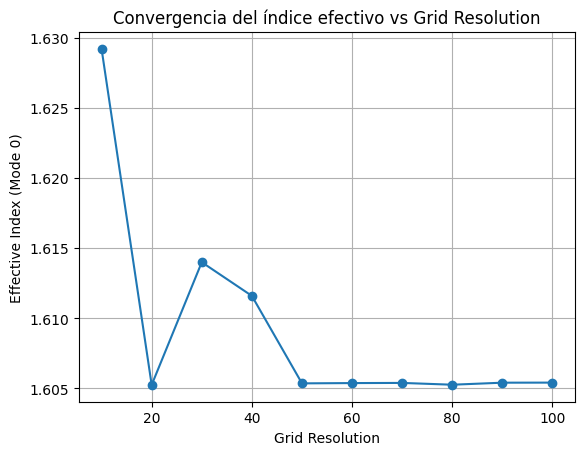

In [3]:
n_eff = []

grid_resolutions = np.arange(10, 101, 10)

for i in grid_resolutions:
    deep_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=1.2, # Waveguide width
        core_thickness=300 * nm, # Waveguide height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=1550 * nm, # Wavelength to simulate
        num_modes=4, # Targeted number of modes to find 
        max_grid_scaling=1.5, # Parameters of the grid 
        grid_resolution=i, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )
    n_eff.append(deep_waveguide.n_eff[0])

plt.figure()
plt.plot(grid_resolutions, n_eff, 'o-')
plt.xlabel("Grid Resolution")
plt.ylabel("Effective Index (Mode 0)")
plt.title("Convergencia del índice efectivo vs Grid Resolution")
plt.grid(True)
plt.show()


2026-02-23 18:26:21.483 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_29761b037c0c9026.npz.
2026-02-23 18:26:21.485 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_fbe312fd02002ae4.npz.
2026-02-23 18:26:21.486 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_76e2764f504071ba.npz.
2026-02-23 18:26:21.487 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_cf92515ae4232c65.npz.
2026-02-23 18:26:21.488 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_683206c3f01233c4.npz.


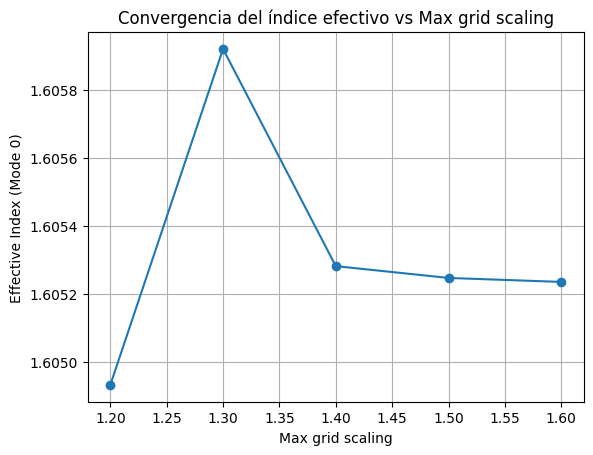

In [4]:
n_eff = []

max_grid_scaling=np.linspace(1.2,1.6,5)

for i in max_grid_scaling:
    deep_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=1.2, # Waveguide width
        core_thickness=300 * nm, # Waveguide height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=1550 * nm, # Wavelength to simulate
        num_modes=4, # Targeted number of modes to find 
        max_grid_scaling=i, # Parameters of the grid 
        grid_resolution=20,                   
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )
    n_eff.append(deep_waveguide.n_eff[0])

plt.figure()
plt.plot(max_grid_scaling,n_eff,'o-')
plt.xlabel("Max grid scaling")
plt.ylabel("Effective Index (Mode 0)")
plt.title("Convergencia del índice efectivo vs Max grid scaling")
plt.grid(True)
plt.show()


## LO.2. Width dependence

- Perform a sweep of the **deep** waveguide width. Use the code provided in the following cell or program your own sweep. 

  0%|          | 0/11 [00:00<?, ?it/s]

2026-02-23 18:26:21.557 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_b709aaddd3650849.npz.
2026-02-23 18:26:21.559 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_7b5d617676b7b484.npz.
2026-02-23 18:26:21.560 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_19788afb20555fb2.npz.
2026-02-23 18:26:21.561 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_7aafeeac46405a15.npz.
2026-02-23 18:26:21.563 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_6374b7aa3461078b.npz.
2026-02-23 18:26:21.563 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_3d7d22d1954b8509.npz.
2026-02-23 18:26:21.565 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_cf92515ae4232c65.npz.
2026-02-23 18:26:21.566 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_2bdf1aab784d3a25.npz.


  0%|          | 0/11 [00:00<?, ?it/s]

2026-02-23 18:26:21.575 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_b709aaddd3650849.npz.
2026-02-23 18:26:21.577 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_7b5d617676b7b484.npz.
2026-02-23 18:26:21.578 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_19788afb20555fb2.npz.
2026-02-23 18:26:21.580 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_7aafeeac46405a15.npz.
2026-02-23 18:26:21.581 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_6374b7aa3461078b.npz.
2026-02-23 18:26:21.582 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_3d7d22d1954b8509.npz.
2026-02-23 18:26:21.584 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_cf92515ae4232c65.npz.
2026-02-23 18:26:21.585 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_2bdf1aab784d3a25.npz.


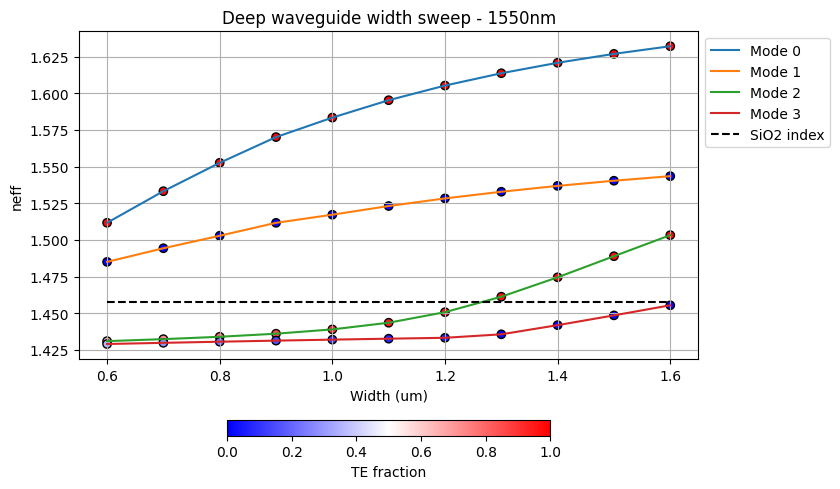

In [5]:
wavelength = 1550 * nm # Student code here

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=1.2,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    slab_thickness=0 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.5,
    grid_resolution=20, 
)

w = np.linspace(600,1600,11)*nm # Student code here

sweep_neff = gt.modes.sweep_n_eff(deep_waveguide, 
                             core_width=w)

sweep_tefraction = gt.modes.sweep_fraction_te(deep_waveguide,
                                              core_width=w)

plt.figure(figsize=(10, 5))
for k in range(sweep_neff.shape[1]):
    plt.scatter(w, sweep_neff[:,k].real,edgecolors='k',c=sweep_tefraction.sel(mode_index=k),vmin=0, vmax=1,label = '__nolegend__',cmap='bwr')
    plt.plot(w, sweep_neff[:,k].real,label=f'Mode {k}')

plt.title("Deep waveguide width sweep - 1550nm")
plt.xlabel("Width (um)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w), xmax=np.max(w), colors='k', linestyles='dashed',label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.colorbar(orientation='horizontal',fraction=0.04).set_label("TE fraction")

## LO.3. Waveguide compact model

A compact model of an integrated photonic waveguide is a reduced-order mathematical model that describes the waveguide’s optical behavior—such as phase propagation, loss, and dispersion, using analytical or semi-analytical equations. Consider: 

Transfer function for propagation in a waveguide:

$$
H(\lambda)
= e^{-j\,\beta(\lambda)\,z}
= e^{-j\,\mathrm{Re}\{\beta(\lambda)\}\,z}\,
  e^{\mathrm{Im}\{\beta(\lambda)\}\,z}.
$$

Where 

$$
\beta(\lambda)
= \frac{2\pi}{\lambda}\,\mathrm{Re}\{n_\mathrm{eff}(\lambda)\}.
$$

Let's model the waveguide's effective index wavelength variation using a second order polynomial:

$$
n_\mathrm{eff}(\lambda)
= n_{1} + n_{2}\,(\lambda-\lambda_{0}) + n_{3}\,(\lambda-\lambda_{0})^{2}
$$

Where 

1. 
$$
n_\mathrm{eff}(\lambda_0) = n_1
$$
2. 
$$
n_g(\lambda_0) = n_1 - n_2\,\lambda_0
$$
3. 
$$
D = -\frac{2\,\lambda_0\,n_3}{c}\;\;[\mathrm{s}^2/\mathrm{m}]
$$

- Find the **compact models** of the following waveguides: 
    - Deep waveguide, height = 300nm, width = 1.2um 
    - Shallow waveguide, core height = 300nm, slab height = 150 nm, width = 1.2um 

**TIP**. Use the Lab0.1.Modesolver results (neff vs lambda) as starting point. Fit the results using a second order polynomial (with the lambda_0 shift) and relate the fit results to n_g and D values. ng=2

2026-02-23 18:26:21.751 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_5db63339a65fc92c.npz.


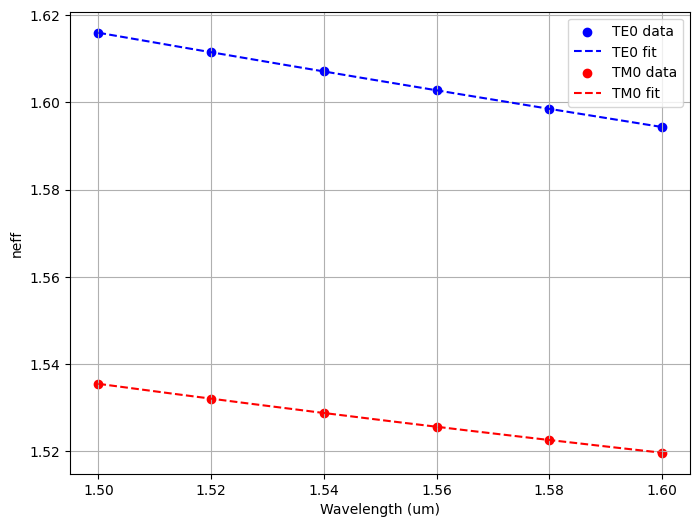

(np.float64(1.939991891860367),
 np.float64(1.772051201012389),
 np.float64(-1.0059815590826712e-18),
 np.float64(-1.5895906965009064e-18),
 np.float64(1.6049166299478341),
 np.float64(1.5271892344779452))

In [6]:
# STUDENT! Put your code here.
wavelength = np.linspace(1500,1600,6) * nm  # Student code here. Tip np.linspace()
central = 1550*nm

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=1.2, 
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

res_neff = deep_waveguide.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te = deep_waveguide.fraction_te # Wavelength-dependent vector
res_tm =deep_waveguide.fraction_tm # Wavelength-dependent vector
neff_TE0 = res_neff[:,0].real

coef_TE = np.polyfit(wavelength - central,neff_TE0,2)

n1_TE = coef_TE[2]
n2_TE = coef_TE[1]
n3_TE = coef_TE[0]

ng_TE = n1_TE - central*n2_TE
D_TE = -(2*central*10**(-9)*n3_TE)/3e8

neff_TM0 = res_neff[:,1].real

coef_TM = np.polyfit(wavelength- central,neff_TM0,2)

n1_TM = coef_TM[2]
n2_TM = coef_TM[1]
n3_TM = coef_TM[0]

ng_TM = n1_TM - central*n2_TM
D_TM = -(2*central*10**(-9)*n3_TM)/3e8

lambda_plot = np.linspace(min(wavelength), max(wavelength), 200)
x_plot = lambda_plot - central

fit_TE = np.polyval(coef_TE, x_plot)
fit_TM = np.polyval(coef_TM, x_plot)

plt.figure(figsize=(8,6))

# TE0
plt.scatter(wavelength, neff_TE0, color='blue', label='TE0 data')
plt.plot(lambda_plot, fit_TE, 'b--', label='TE0 fit')

# TM0
plt.scatter(wavelength, neff_TM0, color='red', label='TM0 data')
plt.plot(lambda_plot, fit_TM, 'r--', label='TM0 fit')

plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.legend()
plt.grid()
plt.show()

ng_TE, ng_TM, D_TE, D_TM, n1_TE,n1_TM

2026-02-23 18:26:21.826 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_e460008e18426a1b.npz.


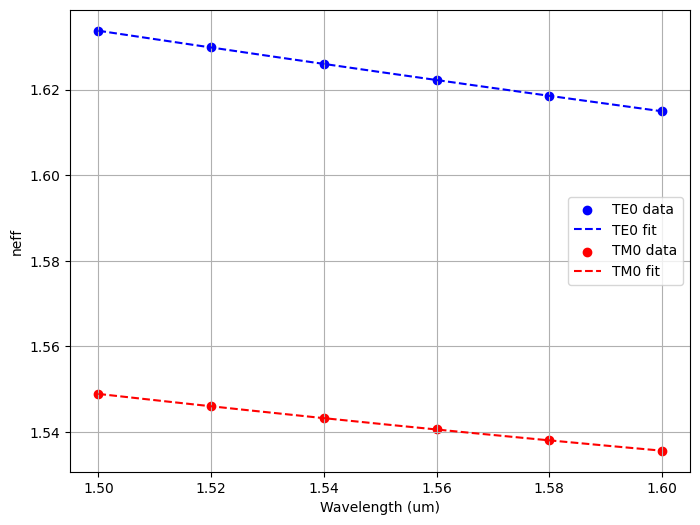

(np.float64(1.9157668978208893),
 np.float64(1.7475136119950536),
 np.float64(-9.888475685264203e-19),
 np.float64(-1.5296556323947894e-18),
 np.float64(1.6240906301147096),
 np.float64(1.5418953561815338))

In [7]:
# The wavelength could be a vector also
wavelength = np.linspace(1500,1600,6) * nm  # Student code here. Tip np.linspace()

shallow_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=1.2, 
    slab_thickness=150 * nm,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

res_neff = shallow_waveguide.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te = shallow_waveguide.fraction_te # Wavelength-dependent vector
res_tm =shallow_waveguide.fraction_tm # Wavelength-dependent vector

neff_TE0 = res_neff[:,0].real

coef_TE = np.polyfit(wavelength - central,neff_TE0,2)

n1_TE = coef_TE[2]
n2_TE = coef_TE[1]
n3_TE = coef_TE[0]

ng_TE = n1_TE - central*n2_TE
D_TE = -(2*central*10**(-9)*n3_TE)/3e8

neff_TM0 = res_neff[:,1].real

coef_TM = np.polyfit(wavelength- central,neff_TM0,2)

n1_TM = coef_TM[2]
n2_TM = coef_TM[1]
n3_TM = coef_TM[0]

ng_TM = n1_TM - central*n2_TM
D_TM = -(2*central*10**(-9)*n3_TM)/3e8

lambda_plot = np.linspace(min(wavelength), max(wavelength), 200)
x_plot = lambda_plot - central

fit_TE = np.polyval(coef_TE, x_plot)
fit_TM = np.polyval(coef_TM, x_plot)

plt.figure(figsize=(8,6))

# TE0
plt.scatter(wavelength, neff_TE0, color='blue', label='TE0 data')
plt.plot(lambda_plot, fit_TE, 'b--', label='TE0 fit')

# TM0
plt.scatter(wavelength, neff_TM0, color='red', label='TM0 data')
plt.plot(lambda_plot, fit_TM, 'r--', label='TM0 fit')

plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.legend()
plt.grid()
plt.show()

ng_TE, ng_TM, D_TE, D_TM, n1_TE,n1_TM

## LO.4. Bend waveguide radius vs. loss – deep

The bend loss has three primary contributions:

1. Mode-mismatch loss
2. Radiation loss
3. Propagation loss

2026-02-23 18:26:21.896 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_b97dbd964363a565.npz.


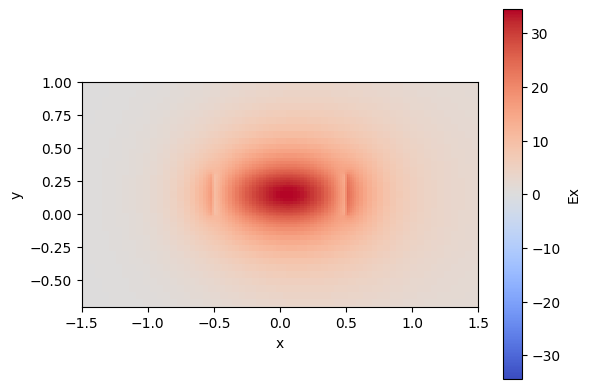

In [8]:
bend_1550 = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=1,
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30, 
    bend_radius=20, # Bend radius
)

bend_1550.plot_field(field_name="Ex", 
                     mode_index=0, # Field to be plotted
                     value='real', # Real - abs - imag
                     cmap='coolwarm',
                     xlim=(-1.5, 1.5), # Set the x and y limits
                     ylim=(-0.7, 1)) 


### Mode-mismatch loss

Bend waveguide mode differs slightly from the straight waveguide mode, wich yield into mode-convertion losses. We can calculate this factor with as the overlap of the latter two modes. 

This is already implemented on GDSfactory library: 

  0%|          | 0/10 [00:00<?, ?it/s]

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.ve

Text(0, 0.5, 'Mismatch (dB)')

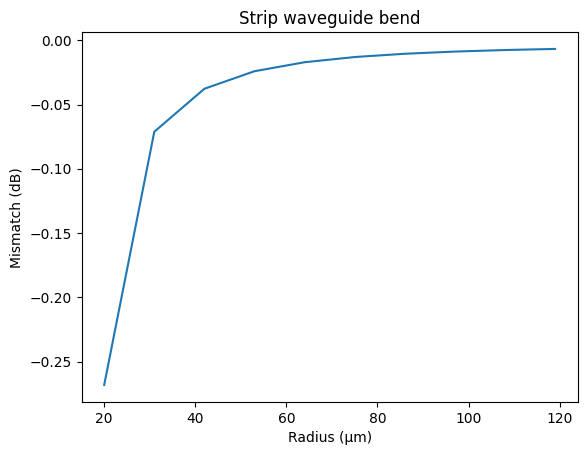

In [9]:
radii = np.arange(20.0, 120,11)

mismatch = gt.modes.sweep_bend_mismatch(bend_1550, radii)

plt.plot(radii, 10 * np.log10(mismatch))
plt.title("Strip waveguide bend")
plt.xlabel("Radius (μm)")
plt.ylabel("Mismatch (dB)")

### Propagation loss

Consider the equivalent linear length of the quarter-circle bend. Light will attenuate following a trend quantified with the experimentally measured parameter $$\alpha [\mathrm{dB}/\mathrm{cm}]$$. It depends on the fabrication process mainly. We will add this loss (in dBs) to the mode-mismatch loss to calculate the total loss per bend. 

*We are not considering the radiation losses, mainly because is not easy to implement a quick simulation for this parameter. Under certain conditions, the main loss sources are the ones considered in this example


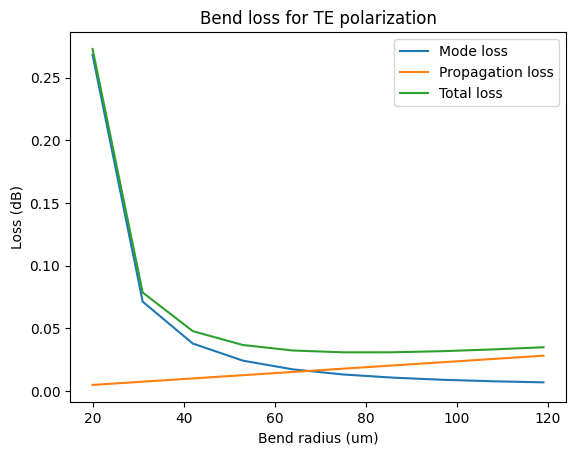

In [10]:
dB_cm = 1.5  # dB/cm Technology loss - 
length = 0.5 * np.pi * radii * 1e-6
propagation_loss = dB_cm * length * 1e2
propagation_loss

plt.title("Bend loss for TE polarization")
plt.plot(radii, -10 * np.log10(mismatch), label="Mode loss")
plt.plot(radii, propagation_loss,  label="Propagation loss")
plt.plot(radii, propagation_loss-10 * np.log10(mismatch), label="Total loss")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB)")
plt.legend()

- Use the code provided in this section to calculate the safe radius for 1.2 um width deep waveguides at 1.5 um. 

  0%|          | 0/21 [00:00<?, ?it/s]

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.ve

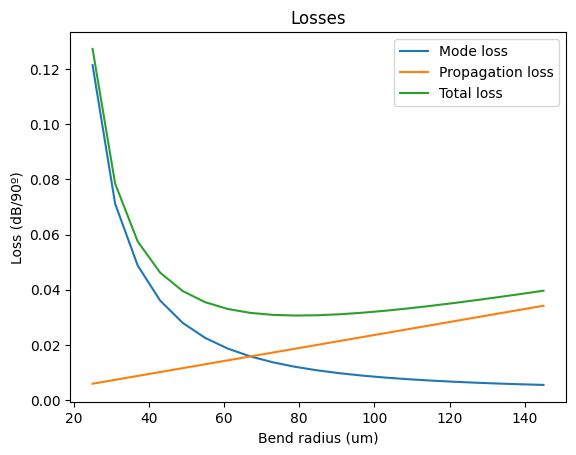

In [11]:
radii = np.arange(25.0, 150,6)
propagation_loss = radii*(np.pi/2)*(dB_cm/10000)
mismatch = gt.modes.sweep_bend_mismatch(bend_1550, radii)


plt.title("Losses")
plt.plot(radii, -10 * np.log10(mismatch), label="Mode loss")
plt.plot(radii, propagation_loss,  label="Propagation loss")
plt.plot(radii, propagation_loss-10 * np.log10(mismatch), label="Total loss")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB/90º)")
plt.legend()

2026-02-23 18:27:22.978 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_9ef0e4a67778fb34.npz.
2026-02-23 18:27:22.980 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_0ad005e192b02f14.npz.
2026-02-23 18:27:22.981 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_348ceacd09a625ac.npz.
2026-02-23 18:27:22.982 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_37924a56b1fa12eb.npz.
2026-02-23 18:27:22.984 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_c45033e6906d88c7.npz.
2026-02-23 18:27:22.986 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_e01742440a0a3409.npz.


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


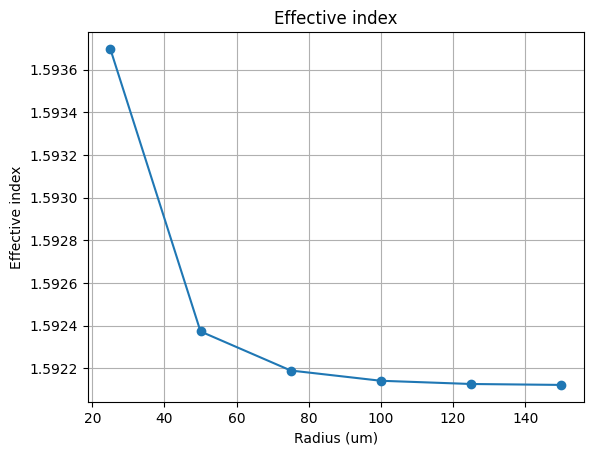

In [12]:
radio = np.linspace(25,150,6)
neff = []
for i in radio:
    bend_1550 = gt.modes.Waveguide(
        wavelength=1550 * nm,
        core_width=1,
        slab_thickness=0.0,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300 * nm,
        num_modes=1,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.2,
        grid_resolution=30, 
        bend_radius=i, # Bend radius
    )
    neff.append(bend_1550.n_eff)

plt.figure()
plt.plot(radio, neff, 'o-')
plt.ylabel("Effective index")
plt.xlabel("Radius (um)")
plt.title("Effective index")
plt.grid(True)
plt.show()


## EXTRA

All the past simulations were done considering as core material de Silicon Nitride (SiNx) and Silicon Dioxide (SiO2) as cladding material. Now, **simulate the Silicon-On-Insulator technology changing the core material to Silicon (Si)**. In this case, the dimensions will be 220 nm heigth and 500 nm width. 
1. Repeat the LO.1. wavelength behavior simulations, considering the updated materials and dimensions. 
2. Repeat the LO.2. width dependence analysis, now sweeping in a 300nm - 1um range. 
3. Find the safe radius for this technology. Consider sweeping the radius in a 5um to 30um range. 
4. **Compare the SiNx and SOI technologies** 

18:29:21 Hora estándar romance WARNING: frequency passed to                     
                               'Medium.eps_model()'is outside of                
                               'Medium.frequency_range' = (206753419710997.8,   
                               1199169834323787.2)                              

2026-02-23 18:29:21.504 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_555496046cbcf8ad.npz.
2026-02-23 18:29:21.506 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_0866d3aa55a99d6e.npz.
2026-02-23 18:29:21.507 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_2e7d1521ebf07a15.npz.
2026-02-23 18:29:21.509 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_3700896b1b09c109.npz.
2026-02-23 18:29:21.511 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_2183132b4423dfc3.npz.
2026-02-23 18:29:21.513 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_e08b5e67d3caaffc.npz.
2026-02-23 18:29:21.514 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_5fc3b132dc8994ee.npz.
2026-02-23 18:29:21.515 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_f1bd95ac3b6345cc.npz.


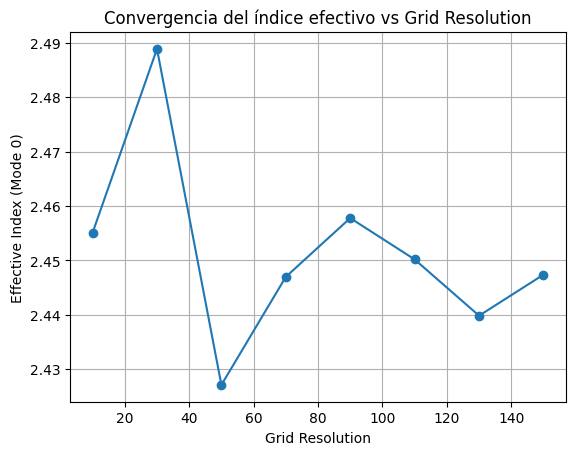

In [19]:
si_complex = td.material_library["cSi"]["Green2008"].eps_model(f)
si_index, si_k = td.Medium.eps_complex_to_nk(si_complex)

n_eff = []

grid_resolutions = np.arange(10, 170, 20)

for i in grid_resolutions:
    deep_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=500 * nm, # Waveguide width
        core_thickness=220 * nm, # Waveguide height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        # Materials
        core_material='si', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=1550 * nm, # Wavelength to simulate
        num_modes=4, # Targeted number of modes to find 
        max_grid_scaling=1.5, # Parameters of the grid 
        grid_resolution=i, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )
    n_eff.append(deep_waveguide.n_eff[0])

plt.figure()
plt.plot(grid_resolutions, n_eff, 'o-')
plt.xlabel("Grid Resolution")
plt.ylabel("Effective Index (Mode 0)")
plt.title("Convergencia del índice efectivo vs Grid Resolution")
plt.grid(True)
plt.show()


2026-02-23 18:37:37.847 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_e57b1482e9676d81.npz.


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.ve

18:37:41 Hora estándar romance WARNING: Mode field at frequency index 0, mode   
                               index 3 does not decay at the plane boundaries.  

2026-02-23 18:37:41.801 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\Waveguide_e3275e7e62cc8016.npz.


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.ve

...

2026-02-23 18:38:05.866 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\Waveguide_641a325a6708068f.npz.


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.ve

18:38:09 Hora estándar romance WARNING: Mode field at frequency index 0, mode   
                               index 3 does not decay at the plane boundaries.  

2026-02-23 18:38:09.665 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\Waveguide_9131159f9e48a3d7.npz.
2026-02-23 18:38:09.678 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_322d6affdb478ce7.npz.


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


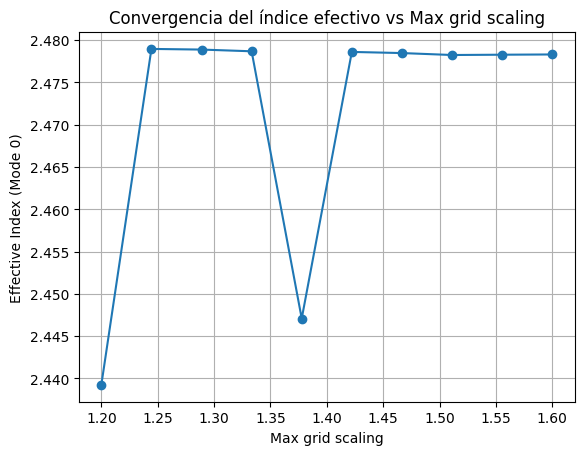

In [30]:
n_eff = []

max_grid_scaling=np.linspace(1.2,1.6,10)

for i in max_grid_scaling:
    deep_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=500 * nm, # Waveguide width
        core_thickness=220 * nm, # Waveguide height
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        # Materials
        core_material='si', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=1550 * nm, # Wavelength to simulate
        num_modes=4, # Targeted number of modes to find 
        max_grid_scaling=i, # Parameters of the grid 
        grid_resolution=40,                   
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )
    n_eff.append(deep_waveguide.n_eff[0])

plt.figure()
plt.plot(max_grid_scaling,n_eff,'o-')
plt.xlabel("Max grid scaling")
plt.ylabel("Effective Index (Mode 0)")
plt.title("Convergencia del índice efectivo vs Max grid scaling")
plt.grid(True)
plt.show()

  0%|          | 0/11 [00:00<?, ?it/s]

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.ve

18:38:50 Hora estándar romance WARNING: Mode field at frequency index 0, mode   
                               index 2 does not decay at the plane boundaries.  

18:38:51 Hora estándar romance WARNING: Mode field at frequency index 0, mode   
                               index 3 does not decay at the plane boundaries.  

2026-02-23 18:38:51.025 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\Waveguide_4875837e6f09544a.npz.


...

2026-02-23 18:39:31.890 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\Waveguide_abeebfcc60bc48ce.npz.


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.ve

2026-02-23 18:39:36.318 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\Waveguide_c6f941a9f80f196d.npz.


  0%|          | 0/11 [00:00<?, ?it/s]

2026-02-23 18:39:36.336 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_4875837e6f09544a.npz.
2026-02-23 18:39:36.380 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_53076179472a9fe0.npz.
2026-02-23 18:39:36.416 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_b8d5c12ffa700fe2.npz.
2026-02-23 18:39:36.461 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_19ddb7579d1a0f38.npz.
2026-02-23 18:39:36.505 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_c67f3b1e6b299bbf.npz.
2026-02-23 18:39:36.541 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_ab1d2342f8c55ea0.npz.
2026-02-23 18:39:36.578 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_dd33d3a3de845860.npz.
2026-02-23 18:39:36.625 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_32eb8730f2b501f8.npz.


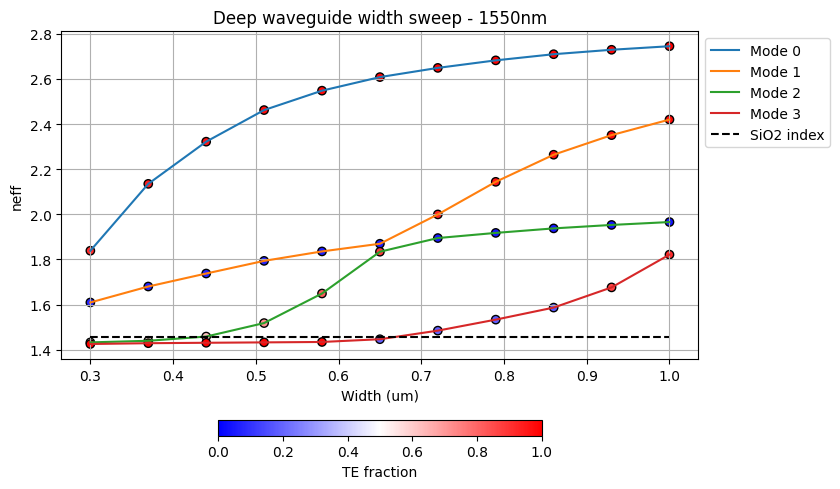

In [31]:
wavelength = 1550 * nm # Student code here

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=500 * nm,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    slab_thickness=0 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.45,
    grid_resolution=40, 
)

w = np.linspace(0.3,1,11) # Student code here

sweep_neff = gt.modes.sweep_n_eff(deep_waveguide, 
                             core_width=w)

sweep_tefraction = gt.modes.sweep_fraction_te(deep_waveguide,
                                              core_width=w)

plt.figure(figsize=(10, 5))
for k in range(sweep_neff.shape[1]):
    plt.scatter(w, sweep_neff[:,k].real,edgecolors='k',c=sweep_tefraction.sel(mode_index=k),vmin=0, vmax=1,label = '__nolegend__',cmap='bwr')
    plt.plot(w, sweep_neff[:,k].real,label=f'Mode {k}')

plt.title("Deep waveguide width sweep - 1550nm")
plt.xlabel("Width (um)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w), xmax=np.max(w), colors='k', linestyles='dashed',label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.colorbar(orientation='horizontal',fraction=0.04).set_label("TE fraction")

  0%|          | 0/3 [00:00<?, ?it/s]

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.ve

  0%|          | 0/3 [00:00<?, ?it/s]

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab1\.ve

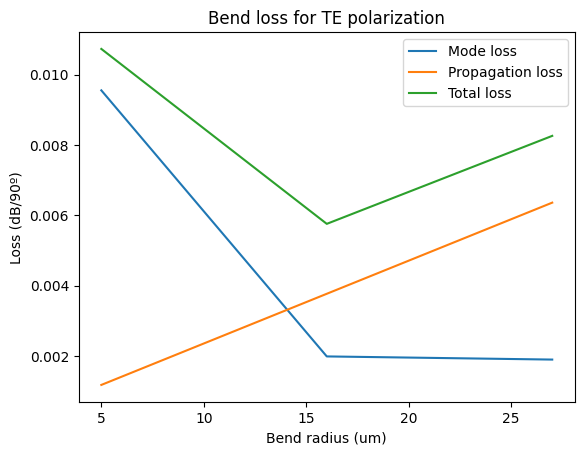

In [33]:
bend_1550 = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=500 * nm,
    slab_thickness=0.0,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.45,
    grid_resolution=40, 
    bend_radius=20, # Bend radius
)

radii = np.arange(5.0, 30,11)

mismatch = gt.modes.sweep_bend_mismatch(bend_1550, radii)

dB_cm = 1.5  # dB/cm Technology loss - 
length = 0.5 * np.pi * radii * 1e-6
propagation_loss = dB_cm * length * 1e2
propagation_loss

propagation_loss = radii*(np.pi/2)*(dB_cm/10000)
mismatch = gt.modes.sweep_bend_mismatch(bend_1550, radii)

5
plt.title("Bend loss for TE polarization")
plt.plot(radii, -10 * np.log10(mismatch), label="Mode loss")
plt.plot(radii, propagation_loss,  label="Propagation loss")
plt.plot(radii, propagation_loss-10 * np.log10(mismatch), label="Total loss")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB/90º)")
plt.legend()

| Tecnología |  Grid resolution | Max grid scaling| Dimensiones|Pérdidas|
|------------|------------------|-----------------|-------------|----------|
| SiNx       | 50             | 1.5           | 300 x 1200   | Altas    |
| SOI        | 40    | 1.45            | 220 x 500    | Bajas   |


En SiNx, los dos primeros modos se propagan siempre, independientemente del ancho de la guía. El tercer modo comienza a propagarse cuando el ancho supera aproximadamente 1.25 µm, y el cuarto modo aparece cuando el ancho es mayor a 1.6 µm.

Por otro lado, en SOI (cSi sobre SiO₂), los dos primeros modos también se propagan siempre, pero el tercer modo aparece con un ancho mayor a ~0.45 µm y el cuarto modo a ~0.65 µm, debido al mayor contraste de índice que permite la propagación de modos superiores con anchos más pequeños.

En cuanto al radio seguro, para SiNx se encuentra en un rango aproximado de [30–150] µm, ya que radios menores producen pérdidas por curvatura significativas.Para radios menores que 70 µm dominan las pérdidas modales y para valores mayores dominarán las de propagación.En SOI, el radio seguro cubre prácticamente todo el rango estudiado [25–150] µm, con pérdidas considerablemente menores que en SiNx, gracias al fuerte confinamiento modal. En este caso, para radios hasta 35 µm dominan las pérdidas modales y para valores mayores dominan las de propagación.

Cada tecnología presenta ventajas y desventajas. Si se desea propagar únicamente los dos primeros modos, SiNx es la opción más adecuada, ya que requiere anchos mayores para que aparezcan modos no deseados, aunque esto implique dispositivos más grandes y mayores pérdidas por propagación recta. Por otro lado, si se priorizan bajas pérdidas y dispositivos compactos, SOI es preferible, aunque la guía se vuelva multimodo a anchos relativamente pequeños.

## Grading

LO.1. 2 Point <br> 
LO.2. 1 Points <br> 
LO.3. 3 Point <br> 
LO.4. 1 Points <br> 
**Total 7 Points** <br>
Extra (Up to) 3 Points
